# Demo 3 · Código asistido por IA
**Decisiones Inteligentes: IA y el Futuro de las Empresas** — IMEF Morelos, 16 de julio de 2026

Ventas mensuales de una empresa ficticia: **5 sucursales, 18 meses**. Todo el análisis que sigue se pide en lenguaje natural al asistente de IA de Colab — sin escribir código.

> **VERSIÓN DE RESPALDO** — misma demo con el código ya generado y ejecutado, por si Colab o su asistente fallan en vivo.

In [1]:
import pandas as pd

URL = "https://raw.githubusercontent.com/benjov/imef-decisiones-inteligentes/main/notebooks/data/ventas_sucursales.csv"
try:
    df = pd.read_csv(URL)
except Exception:
    df = pd.read_csv("data/ventas_sucursales.csv")   # respaldo local

df["fecha"] = pd.to_datetime(df["fecha"])
df["venta"] = df["unidades"] * df["precio_unitario"]
print(f"{len(df):,} registros · {df['sucursal'].nunique()} sucursales · {df['fecha'].dt.to_period('M').nunique()} meses")
df.head()

360 registros · 5 sucursales · 18 meses


,fecha,sucursal,producto,unidades,precio_unitario,costo_unitario,venta
0,2024-07-01,Cuernavaca Centro,Kit Industrial,95,5292.64,3106.29,502800.80
1,2024-07-01,Cuernavaca Centro,Línea Hogar,47,1460.55,895.25,68645.85
2,2024-07-01,Cuernavaca Centro,Refacciones,51,893.02,517.10,45544.02
3,2024-07-01,Cuernavaca Centro,Consumibles,57,323.25,207.99,18425.25
4,2024-07-01,Cuernavaca Norte,Kit Industrial,77,5254.49,3103.16,404595.73


## 🎤 Prompts guía (para dictar en vivo al asistente de IA de Colab)

1. **"Muéstrame las ventas totales por sucursal en una gráfica de barras."**
2. **"¿Qué sucursal está en declive? Muéstrame su tendencia mensual."**
3. **"Hazme un análisis de rentabilidad por producto y dame 3 conclusiones en español."**

> La distancia entre *"tengo una pregunta sobre mis datos"* y *"tengo la respuesta"* se redujo a saber **preguntar bien**.

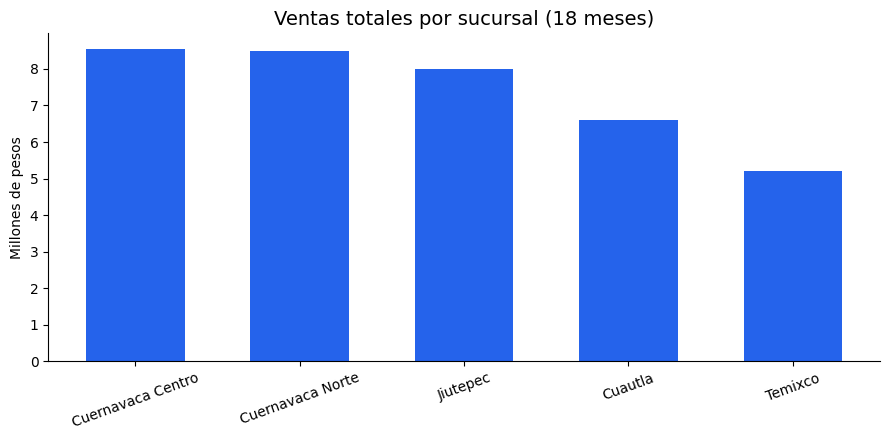

sucursal
Cuernavaca Centro    $8.5 M
Cuernavaca Norte     $8.5 M
Jiutepec             $8.0 M
Cuautla              $6.6 M
Temixco              $5.2 M
Name: venta, dtype: object

In [2]:
# Prompt 1: "Muéstrame las ventas totales por sucursal en una gráfica de barras."
import matplotlib.pyplot as plt

ventas_suc = df.groupby("sucursal")["venta"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
colores = ["#2563EB"] * len(ventas_suc)
ax.bar(ventas_suc.index, ventas_suc.values / 1e6, color=colores, width=0.6)
ax.set_title("Ventas totales por sucursal (18 meses)", fontsize=14)
ax.set_ylabel("Millones de pesos")
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

ventas_suc.apply(lambda v: f"${v/1e6:,.1f} M")

Sucursal en declive: Cuernavaca Centro (-35.9% entre el inicio y el final del periodo)


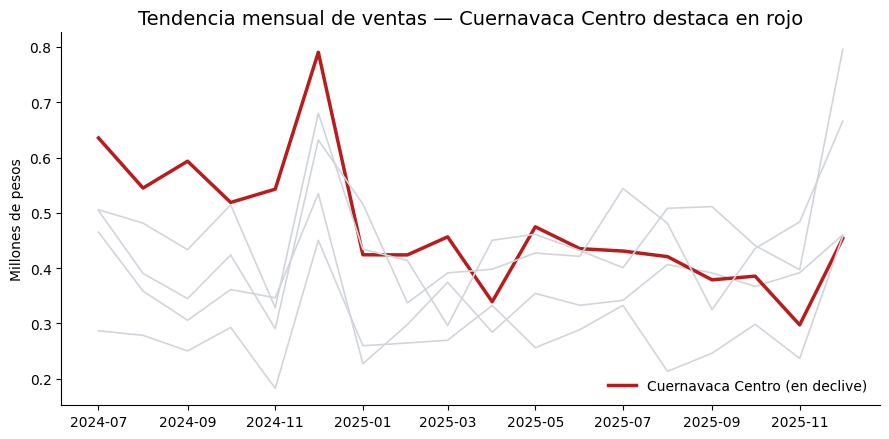

In [3]:
# Prompt 2: "¿Qué sucursal está en declive? Muéstrame su tendencia mensual."
mensual = (df.assign(mes=df["fecha"].dt.to_period("M").dt.to_timestamp())
             .groupby(["mes", "sucursal"])["venta"].sum().unstack())

# comparar el promedio de los últimos 3 meses contra los primeros 3
tendencia = (mensual.tail(3).mean() / mensual.head(3).mean() - 1).sort_values()
en_declive = tendencia.index[0]
print(f"Sucursal en declive: {en_declive} ({tendencia.iloc[0]:+.1%} entre el inicio y el final del periodo)")

fig, ax = plt.subplots(figsize=(9, 4.5))
for col in mensual.columns:
    if col == en_declive:
        ax.plot(mensual.index, mensual[col] / 1e6, color="#B91C1C", lw=2.5, label=f"{col} (en declive)")
    else:
        ax.plot(mensual.index, mensual[col] / 1e6, color="#D1D5DB", lw=1.2)
ax.set_title(f"Tendencia mensual de ventas — {en_declive} destaca en rojo", fontsize=14)
ax.set_ylabel("Millones de pesos")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

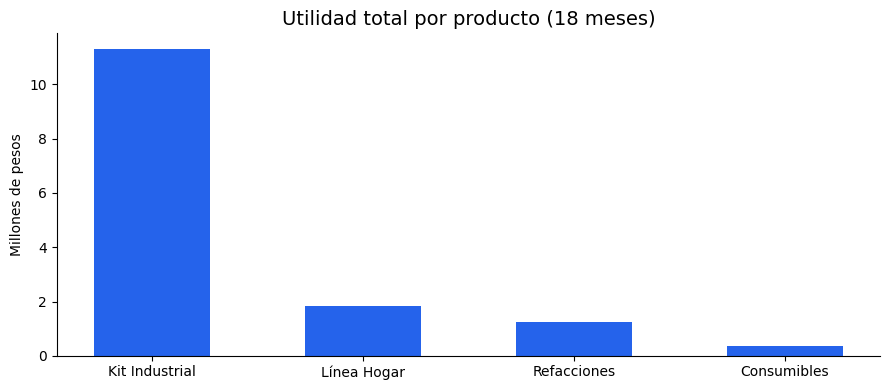

,venta,utilidad,margen
producto,,,
Kit Industrial,"$27,966,106","$11,318,811",40.5%
Línea Hogar,"$4,802,159","$1,822,552",38.0%
Refacciones,"$3,018,613","$1,232,375",40.8%
Consumibles,"$1,057,199","$363,933",34.4%



CONCLUSIONES:
1. "Kit Industrial" es el producto estrella: genera $11.3 M de utilidad
   (77% del total) con margen de 40.5%.
2. Diciembre concentra un pico estacional claro de ventas: conviene planear inventario
   y personal del cierre de año con anticipación.
3. La sucursal en declive detectada arriba requiere un plan comercial específico;
   el resto de la red se mantiene estable o crece.



In [4]:
# Prompt 3: "Hazme un análisis de rentabilidad por producto y dame 3 conclusiones en español."
df["utilidad"] = (df["precio_unitario"] - df["costo_unitario"]) * df["unidades"]
rent = (df.groupby("producto")
          .agg(venta=("venta", "sum"), utilidad=("utilidad", "sum"))
          .assign(margen=lambda t: t["utilidad"] / t["venta"] * 100)
          .sort_values("utilidad", ascending=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rent.index, rent["utilidad"] / 1e6, color="#2563EB", width=0.55)
ax.set_title("Utilidad total por producto (18 meses)", fontsize=14)
ax.set_ylabel("Millones de pesos")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

display(rent.style.format({"venta": "${:,.0f}", "utilidad": "${:,.0f}", "margen": "{:.1f}%"}))

top = rent.index[0]
print(f"""
CONCLUSIONES:
1. "{top}" es el producto estrella: genera ${rent.loc[top, 'utilidad']/1e6:,.1f} M de utilidad
   ({rent.loc[top, 'utilidad']/rent['utilidad'].sum():.0%} del total) con margen de {rent.loc[top, 'margen']:.1f}%.
2. Diciembre concentra un pico estacional claro de ventas: conviene planear inventario
   y personal del cierre de año con anticipación.
3. La sucursal en declive detectada arriba requiere un plan comercial específico;
   el resto de la red se mantiene estable o crece.
""")